In [16]:
import pandas as pd
ltv_final = pd.read_csv('../LTV-Capstone-Project/Customer_LTV_Summary.csv')

The Customer Lifetime Value (CLV) Matrix is a 2-dimensional segmentation tool that classifies customers based on:
1. Purchase Frequency (Horizontal axis) – How often a customer buys.
2. Average Monetary Value (Vertical axis) – How much a customer typically spends per purchase.
- By combining these two factors, the matrix helps visualize where your customers fall in terms of both loyalty and spending power, making it easier to:
- Identify high-value customers (both frequent and big spenders).
- Spot growth opportunities (frequent but low spenders or high spenders who rarely buy).
- Prioritize retention, upsell, and reactivation strategies.

How to interpete?

The CLV matrix gives a bird's-eye view of your customer base:
1. Top-right cell (High Frequency, High Value):
These are your "VIP customers" — they buy often and spend big. Protect and retain them.
2. Bottom-right cell (Low Frequency, High Value):
These are "Big Spenders at Risk" — they spend a lot but rarely return. Target them with retention campaigns.
3. Top-left cell (High Frequency, Low Value):
These are "Frequent but Low Spend" customers — consider cross-selling or upselling.
4. Bottom-left cell (Low Frequency, Low Value):
These are "Low-value, Infrequent Buyers" — lowest priority for retention.

Frequency Segments:
Frequency represents how many repeat transactions a customer has made during their observed lifecycle (in the dataset). Higher frequency segments represent loyal customers or heavy repeat purchasers, which usually indicates a higher likelihood of generating future value.
Customers are split into quantile-based segments based on their frequency value.
Example
pd.qcut(df['frequency_adjusted'], q=4, labels=['Freq_Seg1', 'Freq_Seg2', 'Freq_Seg3', 'Freq_Seg4'])

Frequency Segments:
Value represents the average monetary value per transaction predicted for each customer.
It reflects how much a customer tends to spend when they purchase.
Example
pd.qcut(df['predicted_avg_value'], q=4, labels=['Value_Seg1', 'Value_Seg2', 'Value_Seg3', 'Value_Seg4'])


Important! Dynamic segments calculation
Customer data distributions (frequency and value) are usually not uniform.
If the fixed bins are set manually ( 0–1, 2–5, 6+) one may get empty bins (no customers in some ranges)or fail to capture actual patterns in the data.Dynamic segmentation adjusts automatically based on the data distribution, ensuring:
- Each segment (quartile) contains roughly the same number of customers.
- The CLV Matrix remains meaningful even if the dataset changes (e.g., after new data loads).

C:\Users\dbyst\AppData\Local\Temp\ipykernel_27632\818476032.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cltv_matrix = df.pivot_table(


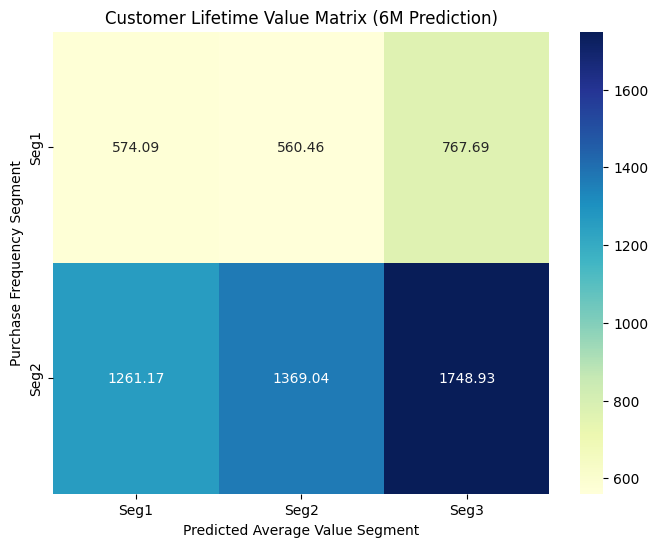

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copy dataset
df = ltv_final.copy()

# Optional: Remove outliers (top 1%)
df = df[df['predicted_LTV_6m'] < df['predicted_LTV_6m'].quantile(0.99)]

# Handle zero frequency
df['frequency_adjusted'] = df['frequency'].replace(0, 0.1)

# Create frequency segments dynamically
freq_bins = pd.qcut(df['frequency_adjusted'], q=4, duplicates='drop')
freq_labels = [f"Seg{i+1}" for i in range(freq_bins.cat.categories.size)]
df['frequency_segment'] = pd.qcut(df['frequency_adjusted'], q=4, labels=freq_labels, duplicates='drop')

# Create value segments dynamically
val_bins = pd.qcut(df['predicted_avg_value'], q=4, duplicates='drop')
val_labels = [f"Seg{i+1}" for i in range(val_bins.cat.categories.size)]
df['value_segment'] = pd.qcut(df['predicted_avg_value'], q=4, labels=val_labels, duplicates='drop')

# Create pivot table
cltv_matrix = df.pivot_table(
    index='frequency_segment',
    columns='value_segment',
    values='predicted_LTV_6m',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cltv_matrix, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Customer Lifetime Value Matrix (6M Prediction)')
plt.xlabel('Predicted Average Value Segment')
plt.ylabel('Purchase Frequency Segment')
plt.show()


In [21]:
ltv_final.head(2)

,customer_id,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_value,predicted_LTV_6m,gender,location,tenure_months
0,12346,0.0,0.0,107.0,0.000,0.486163,1265.594052,615.284554,F,New York,31
1,12347,2.0,223.0,282.0,1163.375,0.867946,1240.987166,1077.109890,M,New York,20


|                    | **Low Value**    | **Medium Value**   | **High Value**         |
| ------------------ | ---------------- | ------------------ | ---------------------- |
| **Low Frequency**  | **At-Risk Low**  | **At-Risk Mid**    | **Potential Loyalist** |
| **High Frequency** | **Frequent Low** | **Core Customers** | **Champions**          |

1. Champions – High spend & high frequency → most valuable, loyal customers.
2. Core Customers – Moderate spend but frequent → stable revenue drivers.
3. Potential Loyalist – High value but low frequency → big spenders who could be nurtured to buy more 4. often.
5. Frequent Low – Low spend but frequent → could be upsold to increase value.
6. At-Risk Mid/Low – Infrequent buyers with low to moderate spend → lowest priority for retention efforts.



C:\Users\dbyst\AppData\Local\Temp\ipykernel_27632\3990680201.py:35: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cltv_matrix = data.pivot_table(


CLTV matrix exported to cltv_matrix.csv


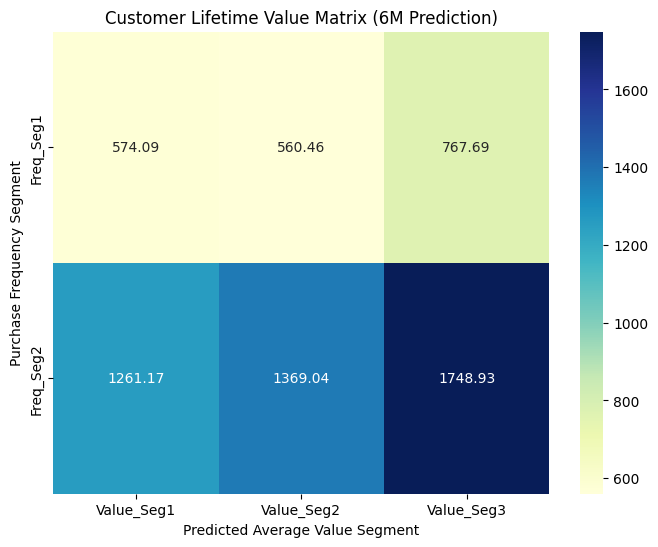

value_segment      Value_Seg1  Value_Seg2  Value_Seg3
frequency_segment                                    
Freq_Seg1              574.09      560.46      767.69
Freq_Seg2             1261.17     1369.04     1748.93


In [18]:
# Create a pivot table to transfer data to Tableau for visualization (frequency segment x value segment)

def generate_cltv_matrix(df, quantiles=4, cap_outliers=True, export_csv=False, file_name="cltv_matrix.csv"):

    data = df.copy()

    # Cap extreme predicted LTV outliers
    if cap_outliers:
        data = data[data['predicted_LTV_6m'] < data['predicted_LTV_6m'].quantile(0.99)]

    # Handle zero purchase frequency
    data['frequency_adjusted'] = data['frequency'].replace(0, 0.1)

    # Create frequency segments dynamically
    freq_bins = pd.qcut(data['frequency_adjusted'], q=quantiles, duplicates='drop')
    freq_labels = [f"Freq_Seg{i+1}" for i in range(freq_bins.cat.categories.size)]
    data['frequency_segment'] = pd.qcut(
        data['frequency_adjusted'],
        q=quantiles,
        labels=freq_labels,
        duplicates='drop'
    )

    # Create value segments dynamically
    val_bins = pd.qcut(data['predicted_avg_value'], q=quantiles, duplicates='drop')
    val_labels = [f"Value_Seg{i+1}" for i in range(val_bins.cat.categories.size)]
    data['value_segment'] = pd.qcut(
        data['predicted_avg_value'],
        q=quantiles,
        labels=val_labels,
        duplicates='drop'
    )

    # Create pivot table for mean LTV
    cltv_matrix = data.pivot_table(
        index='frequency_segment',
        columns='value_segment',
        values='predicted_LTV_6m',
        aggfunc='mean'
    ).round(2)

    # Export to CSV for Tableau if requested
    if export_csv:
        cltv_matrix.reset_index().to_csv(file_name, index=False)
        print(f"CLTV matrix exported to {file_name}")

    # Heatmap Visualization
    plt.figure(figsize=(8, 6))
    sns.heatmap(cltv_matrix, annot=True, fmt=".2f", cmap='YlGnBu')
    plt.title('Customer Lifetime Value Matrix (6M Prediction)')
    plt.xlabel('Predicted Average Value Segment')
    plt.ylabel('Purchase Frequency Segment')
    plt.show()

    return cltv_matrix

# ---- USAGE EXAMPLE ----
cltv_matrix = generate_cltv_matrix(ltv_final, quantiles=4, export_csv=True)
print(cltv_matrix.head())


In [20]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Push your LTV matrix DataFrame 
csv_file_path = 'cltv_matrix.csv'
df = pd.read_csv(csv_file_path)
df.to_sql('cltv_matrix', engine, schema=pg_schema, if_exists='replace', index=False)
#C:\Users\dbyst\OneDrive\Desktop\Neue Fische Bootcamp\LTV-Capstone-Project\cltv_matrix.csv

print("CSV imported successfully!")




CSV imported successfully!


In [22]:
import pandas as pd

def add_customer_segments(df, quantiles=4):
    data = df.copy()

    # Cap outliers at 99th percentile for predicted_LTV_6m
    cap_value = data['predicted_LTV_6m'].quantile(0.99)
    data = data[data['predicted_LTV_6m'] < cap_value]

    # Handle zero purchase frequency to avoid issues in qcut
    data['frequency_adjusted'] = data['frequency'].replace(0, 0.1)

    # Create frequency segments dynamically
    freq_bins = pd.qcut(data['frequency_adjusted'], q=quantiles, duplicates='drop')
    freq_labels = [f"Freq_Seg{i+1}" for i in range(freq_bins.cat.categories.size)]
    data['frequency_segment'] = pd.qcut(
        data['frequency_adjusted'],
        q=quantiles,
        labels=freq_labels,
        duplicates='drop'
    )

    # Create value segments dynamically based on predicted_avg_value
    val_bins = pd.qcut(data['predicted_avg_value'], q=quantiles, duplicates='drop')
    val_labels = [f"Value_Seg{i+1}" for i in range(val_bins.cat.categories.size)]
    data['value_segment'] = pd.qcut(
        data['predicted_avg_value'],
        q=quantiles,
        labels=val_labels,
        duplicates='drop'
    )

    # Now we have segments for the subset of customers without outliers.
    # To keep all original customers, merge back the segments with original df on index/customer ID.

    # If your original df has a unique customer ID column, say 'customer_id', do this:
    # segments = data[['customer_id', 'frequency_segment', 'value_segment']]
    # merged_df = df.merge(segments, on='customer_id', how='left')

    # If index uniquely identifies customers, you can just reindex:
    segments = data[['frequency_segment', 'value_segment']]
    merged_df = df.join(segments)

    return merged_df

# Load your original dataframe
ltv_final = pd.read_csv('../LTV-Capstone-Project/Customer_LTV_Summary.csv')

# Add the segments
ltv_final_with_segments = add_customer_segments(ltv_final, quantiles=4)

# Save back to CSV for Tableau
ltv_final_with_segments.to_csv('../LTV-Capstone-Project/Customer_LTV_Summary_with_segments.csv', index=False)

print(ltv_final_with_segments.head())


   customer_id  frequency  recency      T  monetary_value  \
0        12346        0.0      0.0  107.0           0.000   
1        12347        2.0    223.0  282.0        1163.375   
2        12348        1.0    119.0  192.0         693.731   
3        12350        0.0      0.0   17.0           0.000   
4        12356        0.0      0.0  107.0           0.000   

   predicted_purchases_6m  predicted_avg_value  predicted_LTV_6m gender  \
0                0.486163          1265.594052        615.284554      F   
1                0.867946          1240.987166       1077.109890      M   
2                0.577773          1187.344186        686.015648      M   
3                0.914834          1265.594052       1157.807941      M   
4                0.486163          1265.594052        615.284554      F   

     location  tenure_months frequency_segment value_segment  
0    New York             31         Freq_Seg1    Value_Seg2  
1    New York             20         Freq_Seg2    Value_

In [23]:
ltv_final_with_segments.head(2)

,customer_id,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_value,predicted_LTV_6m,gender,location,tenure_months,frequency_segment,value_segment
0,12346,0.0,0.0,107.0,0.000,0.486163,1265.594052,615.284554,F,New York,31,Freq_Seg1,Value_Seg2
1,12347,2.0,223.0,282.0,1163.375,0.867946,1240.987166,1077.109890,M,New York,20,Freq_Seg2,Value_Seg2


In [24]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Push your LTV matrix DataFrame 
csv_file_path = 'Customer_LTV_Summary_with_segments.csv'
df = pd.read_csv(csv_file_path)
df.to_sql('Customer_LTV_Summary_with_segments.csv', engine, schema=pg_schema, if_exists='replace', index=False)

print("CSV imported successfully!")




CSV imported successfully!
